## Trading System

* Use some sort of signal to indicate when to buy or sell
* We can make money both ways:
    * Long
    * Short
* No matther the outcome, I am not suggesting you try this system with actual money!

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfi
%matplotlib inline

[*********************100%***********************]  1 of 1 completed


KeyError: ('System', 'Change')

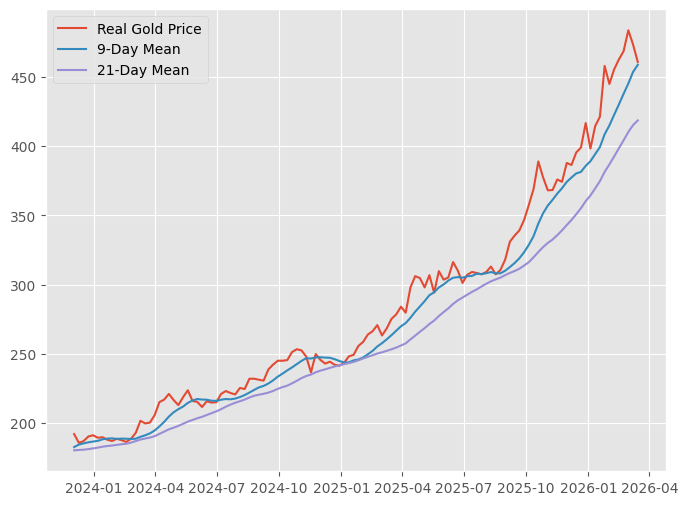

In [ ]:
gld = yfi.download("GLD", start="2018-03-15")
gld = gld.resample("W").last()
gld.tail()

##Format different cells formats
gld['9-Day'] = gld['Close'].rolling(9).mean()
gld['21-Day'] = gld['Close'].rolling(21).mean()
gld['Change'] = gld['Close'] / gld['Close'].shift()
gld.tail()

## Figure the plot
with plt.style.context('ggplot'):
    plt.figure(figsize=(8,6))
    plt.plot(gld['Close'][-120:], label="Real Gold Price")
    plt.plot(gld['9-Day'][-120:], label="9-Day Mean")
    plt.plot(gld['21-Day'][-120:],label="21-Day Mean")
    plt.legend(loc=2)

gld['Position'] = np.where(gld['9-Day'] > gld['21-Day'], 1, -1)
gld['System'] = gld['Position'] * gld['Change']
gld[['System','Change']].cumsum().plot()
gld.tail()